In [37]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils import shuffle  # For shuffling the data

In [38]:
# Directories for training and testing data
train_dir = '../../data/Training'
test_dir = '../../data/Testing'

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training + Validation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Testing (separate dataset)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1602 images belonging to 4 classes.


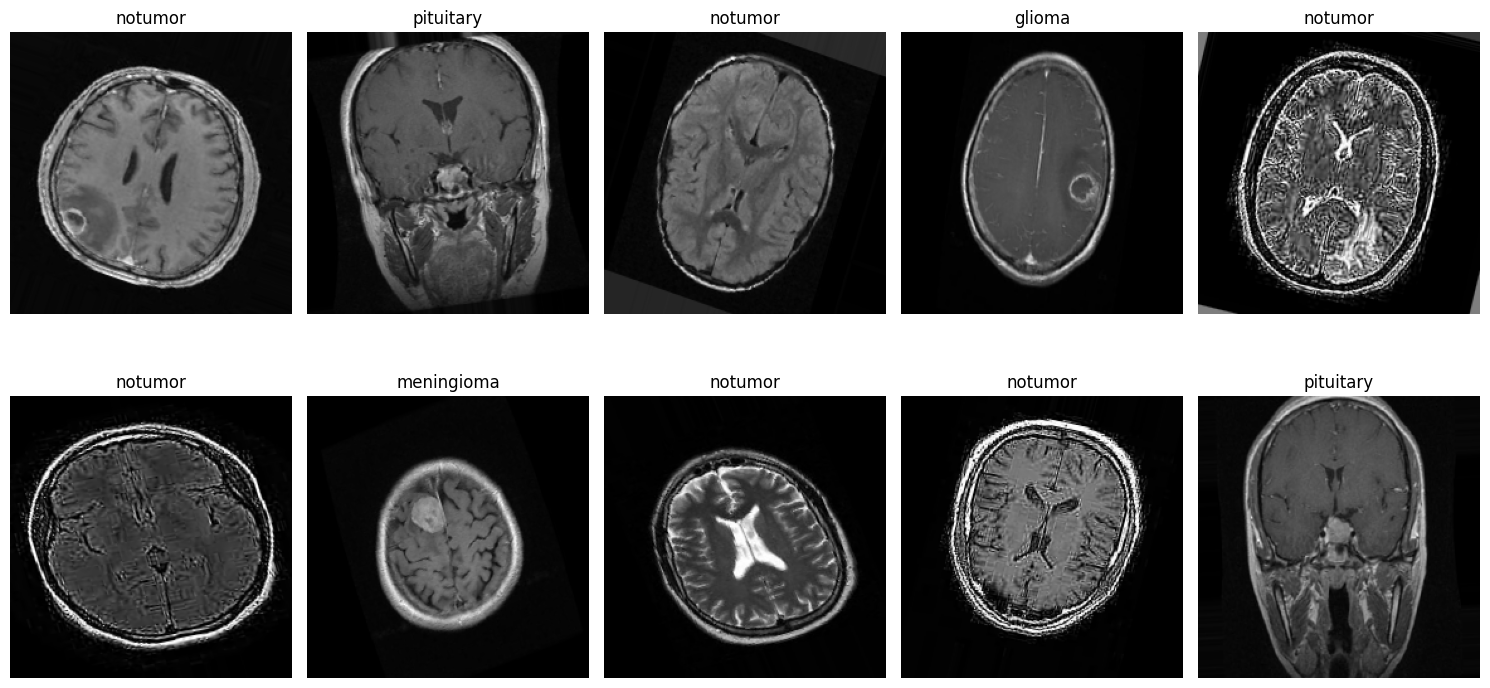

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels = next(train_generator)

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(15,8))

for i in range(10):
    plt.subplot(2,5,i+1)
    
    img = images[i]
    
    # Reverse preprocessing for display (approx)
    img = (img - img.min()) / (img.max() - img.min())
    
    plt.imshow(img)
    plt.axis('off')
    
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])

plt.tight_layout()
plt.show()

In [40]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping

IMAGE_SIZE = 224

base_model = EfficientNetB0(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 50 layers (better than 20)
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Build model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(class_names), activation='softmax')
])

# Compile (FIXED LOSS)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',   
    metrics=['accuracy']
)

# epochs = 15

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop]
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/30
140/140 [==============================] - 165s 1s/step - loss: 0.6993 - accuracy: 0.7344 - val_loss: 0.3525 - val_accuracy: 0.8732
Epoch 2/30
140/140 [==============================] - 138s 984ms/step - loss: 0.3425 - accuracy: 0.8725 - val_loss: 0.2374 - val_accuracy: 0.9027
Epoch 3/30
140/140 [==============================] - 172s 1s/step - loss: 0.2397 - accuracy: 0.9121 - val_loss: 0.1904 - val_accuracy: 0.9339
Epoch 4/30
140/140 [==============================] - 134s 958ms/step - loss: 0.1874 - accuracy: 0.9324 - val_loss: 0.1505 - val_accuracy: 0.9438
Epoch 5/30
140/140 [==============================] - 135s 964ms/step - loss: 0.1457 - accuracy: 0.9487 - val_loss: 0.1512 - val_accuracy: 0.9509
Epoch 6/30
140/140 [==============================] - 129s 921ms/step - loss: 0.1196 - accuracy: 0.9578 - val_loss: 0.1157 - val_accuracy: 0.9625
Epoch 7/30
140/140 [==============================] - 134s 956ms/step - loss: 0.0992 - accuracy: 0.9638 - val_loss: 0.1126 - val_a

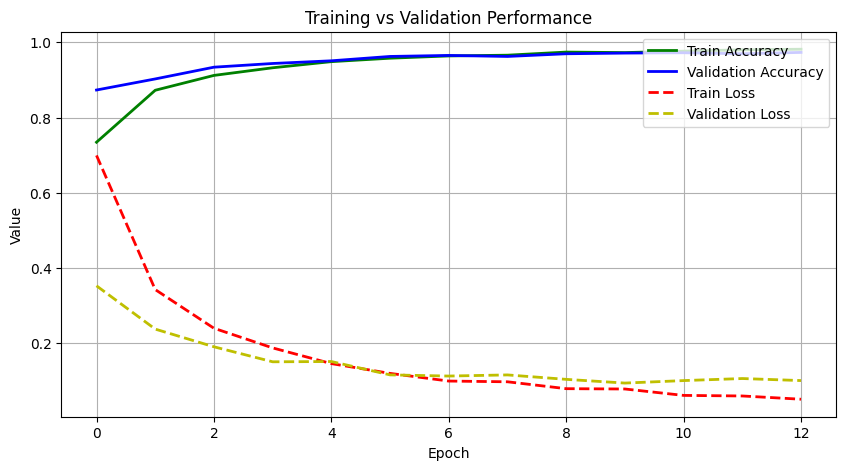

In [41]:
plt.figure(figsize=(10,5))
plt.grid(True)

# Accuracy
plt.plot(history.history['accuracy'], 'g-', linewidth=2)
plt.plot(history.history['val_accuracy'], 'b-', linewidth=2)

# Loss
plt.plot(history.history['loss'], 'r--', linewidth=2)
plt.plot(history.history['val_loss'], 'y--', linewidth=2)

plt.title('Training vs Validation Performance')
plt.xlabel('Epoch')
plt.ylabel('Value')

plt.legend([
    'Train Accuracy',
    'Validation Accuracy',
    'Train Loss',
    'Validation Loss'
], loc='upper right')

plt.show()

In [42]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels
true_labels = test_generator.classes

# Predict
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification Report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

51/51 [==============================] - 27s 472ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.85      0.89       401
  meningioma       0.89      0.92      0.90       400
     notumor       0.95      1.00      0.97       400
   pituitary       0.96      0.99      0.98       401

    accuracy                           0.94      1602
   macro avg       0.94      0.94      0.94      1602
weighted avg       0.94      0.94      0.94      1602



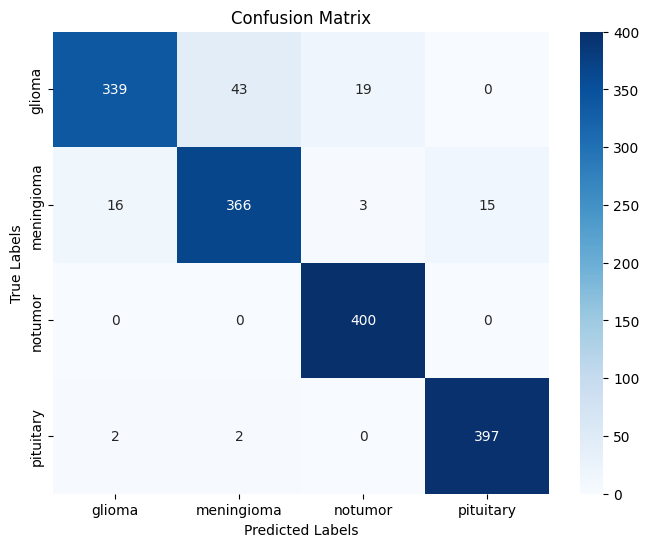

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

51/51 [==============================] - 25s 476ms/step


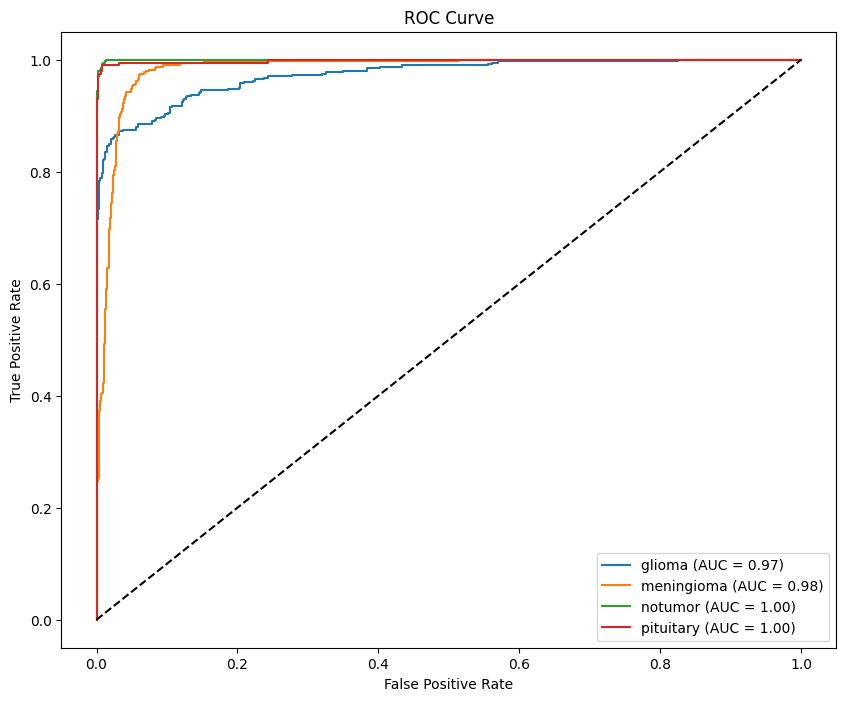

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# True labels
true_labels = test_generator.classes

# Predictions
predictions = model.predict(test_generator)

# Binarize labels
true_labels_bin = label_binarize(true_labels, classes=np.arange(len(class_names)))

# ROC
fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(10,8))

for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [45]:
model.save("brain_tumor_model.keras")

In [46]:
from tensorflow.keras.models import load_model
model = load_model("brain_tumor_model_TF.keras")

In [47]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

class_names = class_names = list(train_generator.class_indices.keys())
print(class_names)



# Class labels
class_labels = class_names

def detect_and_display(img_path, model, image_size=224):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        # top_indices = np.argsort(predictions[0])[-3:][::-1]

        # print("\nTop Predictions:")
        # for i in top_indices:
        #     print(f"{class_names[i]}: {predictions[0][i]*100:.2f}%")
        predicted_class_index = np.argmax(predictions)
        confidence_score = np.max(predictions)

        label = class_names[predicted_class_index]

        if label == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {label}"

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} ({confidence_score*100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error:", e)

['glioma', 'meningioma', 'notumor', 'pituitary']


1/1 [==============================] - 2s 2s/step


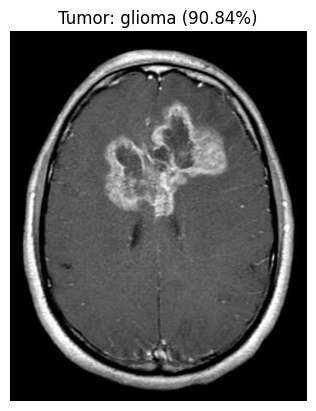

In [48]:
# Example usage
image_path = '../../data/Testing/glioma/Te-gl_1.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

In [49]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


1/1 [==============================] - 0s 115ms/step


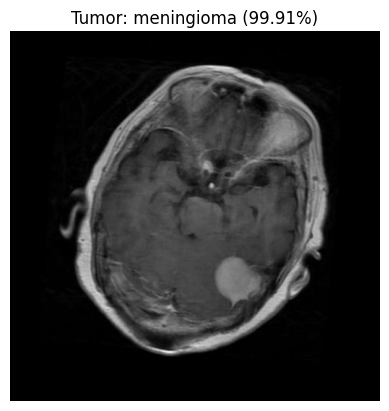

In [50]:
# Example usage
image_path = '../../data/Testing/meningioma/Te-aug-me_1.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 [==============================] - 0s 204ms/step


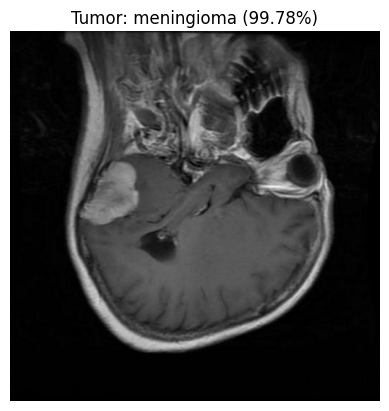

In [51]:

# Example usage
image_path = '../../data/Testing/meningioma/Te-aug-me_20.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 [==============================] - 0s 120ms/step


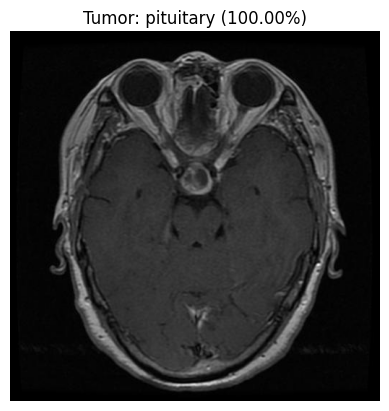

In [52]:
# Example usage
image_path = '../../data/Testing/pituitary/Te-pi_108.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 [==============================] - 0s 109ms/step


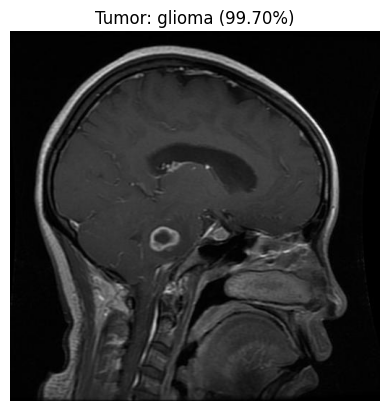

In [53]:
# Example usage
image_path = '../../data/Testing/glioma/Te-gl_210.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

In [54]:
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 4)                

In [55]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import cv2
import numpy as np

def simple_activation_map(img_path, model):

    base_model = model.layers[0]
    last_conv_layer = base_model.get_layer("top_conv")

    activation_model = Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    img = load_img(img_path, target_size=(224,224))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    feature_maps = activation_model.predict(img_array)

    heatmap = np.mean(feature_maps[0], axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    img_cv = cv2.imread(img_path)
    img_cv = cv2.resize(img_cv, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = heatmap * 0.4 + img_cv

    pred = model.predict(img_array)
    pred_index = np.argmax(pred[0])
    confidence = np.max(pred)

    class_names = list(train_generator.class_indices.keys())

    plt.imshow(overlay.astype('uint8'))
    plt.axis('off')
    plt.title(f"{class_names[pred_index]} ({confidence*100:.2f}%)")
    plt.show()

    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.imshow(img_cv)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(overlay.astype('uint8'))
    plt.title("Model Attention")
    plt.axis('off')
    
    plt.show()

    # Explanation
    print("\n Model Explanation:")
    print("Red areas show where the model is focusing the most.")
    print("Yellow areas show moderate attention.")
    print("Blue areas show less important regions.")

    # Prediction
    print("\n Prediction:")
    print(f"Predicted Class: {class_names[pred_index]}")
    print(f"Confidence: {confidence*100:.2f}%")

    # Interpretation
    if class_names[pred_index] != "notumor":
        print("\n Interpretation:")
        print("The model focuses on specific regions of the MRI scan,")
        print("which likely correspond to tumor-affected areas.")
        print("This shows the model is making meaningful decisions.")
    else:
        print("\n Interpretation:")
        print("The model does not focus on any abnormal region,")
        print("indicating no tumor is detected.")

1/1 [==============================] - 0s 99ms/step


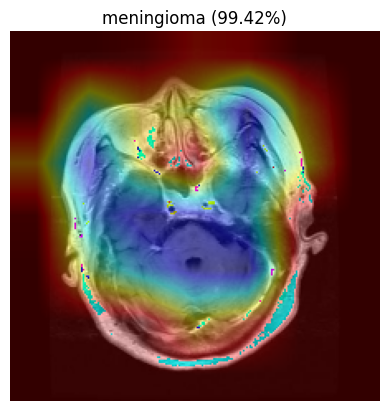

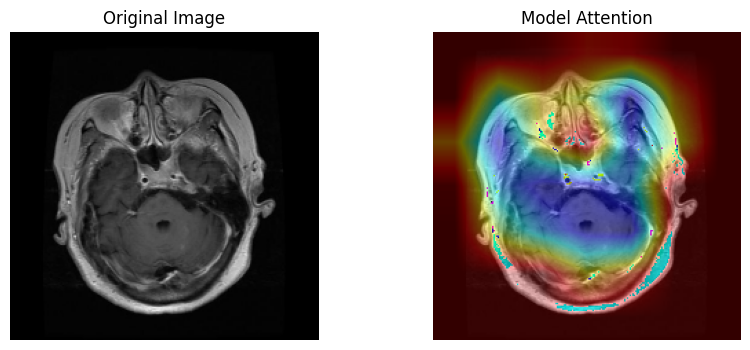


 Model Explanation:
Red areas show where the model is focusing the most.
Yellow areas show moderate attention.
Blue areas show less important regions.

 Prediction:
Predicted Class: meningioma
Confidence: 99.42%

 Interpretation:
The model focuses on specific regions of the MRI scan,
which likely correspond to tumor-affected areas.
This shows the model is making meaningful decisions.


In [56]:
simple_activation_map('../../data/Testing/pituitary/Te-pi_8.jpg', model)